In [33]:
import torch
import torch.nn as nn

import numpy as np
import matplotlib.pyplot as plt

# import src.learning_gradient_flow.gradient_flow_optimizer as gradient_flow_optimizer
from learning_gradient_flow import gradient_flow_optimizer, adam_flow_optimizer

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = 'cpu'
print(f"Using device: {device}")
torch.manual_seed(0)

def get_flattened_parameters(model: nn.Module) -> torch.Tensor:
    params = []
    for p in model.parameters():
        params.append(p.data.clone().view(-1))
    return torch.cat(params)

class SimpleNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(1, 8),
            nn.Tanh(),
            nn.Linear(8, 1)
        )
        # self.layers = nn.Sequential(
        #     nn.Linear(1, 16),
        #     nn.Tanh(),
        #     nn.Linear(16, 16),
        #     nn.Tanh(),
        #     nn.Linear(16, 1)
        # )
    def forward(self, x):
        return self.layers(x)

model = SimpleNet().to(device)

def true_fcn(x):
    return torch.sin(x * np.pi).to(device)

n_data = 500
nl = 0.0
x = 2 * torch.rand(n_data, 1).to(device) - 1
y = true_fcn(x) + nl * torch.randn_like(x)

# print n params
n_params = sum(p.numel() for p in model.parameters())
print(f"Number of parameters: {n_params}")

Using device: cpu
Number of parameters: 25


Epoch 1/3000, Loss: adam_torch: 0.442949, adam_custom: 0.442949, adam_flow: 0.442949
Epoch 151/3000, Loss: adam_torch: 0.108359, adam_custom: 0.108359, adam_flow: 2.646595
Epoch 301/3000, Loss: adam_torch: 0.012390, adam_custom: 0.012390, adam_flow: 0.310495
Epoch 451/3000, Loss: adam_torch: 0.007075, adam_custom: 0.007075, adam_flow: 0.023582
Epoch 601/3000, Loss: adam_torch: 0.003204, adam_custom: 0.003204, adam_flow: 0.022917
Epoch 751/3000, Loss: adam_torch: 0.000906, adam_custom: 0.000906, adam_flow: 0.015528
Epoch 901/3000, Loss: adam_torch: 0.000084, adam_custom: 0.000084, adam_flow: 0.014057
Epoch 1051/3000, Loss: adam_torch: 0.000005, adam_custom: 0.000005, adam_flow: 0.012687
Epoch 1201/3000, Loss: adam_torch: 0.000002, adam_custom: 0.000002, adam_flow: 0.011379
Epoch 1351/3000, Loss: adam_torch: 0.000001, adam_custom: 0.000001, adam_flow: 0.010151
Epoch 1501/3000, Loss: adam_torch: 0.000001, adam_custom: 0.000001, adam_flow: 0.009023
Epoch 1651/3000, Loss: adam_torch: 0.0000

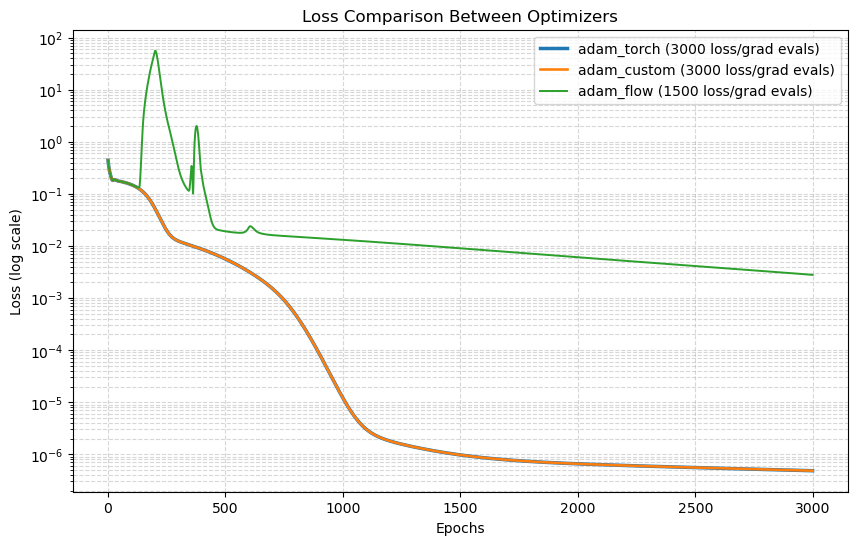

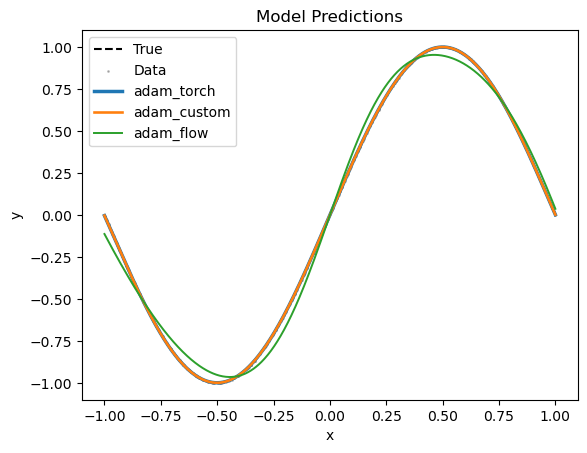

In [34]:
# Training loop
epochs = 3000
batch_size = n_data
# batch_size = n_data // 10
# data loader
train_dataset = torch.utils.data.TensorDataset(x, y)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
n_batches = len(train_loader)

# do above, but easier
# optimizer_names = [
#                 # 'gradient_flow',
#                    'sgd01',
#                 #    'adam001',
#                    'sindy_flow',
#                    'sindy_flow_tr',
#                    'sindy_flow_weak',
#                    'sindy_flow_tr_weak',
#                 #    'sindy_flow_adam'
#                    ]
optimizer_names = [
                    'adam_torch',
                    'adam_custom',
                    'adam_flow'
                  ]
optimizers = {}
for opt_name in optimizer_names:
    optimizers[opt_name] = {
        'model': SimpleNet().to(device),
        'optimizer': None,
        'losses': [],
        'param_history': []
    }

# # Initialize optimizers
# # optimizers['gradient_flow']['optimizer'] = gradient_flow_optimizer.GradientFlow(
# #     optimizers['gradient_flow']['model'].parameters(), dt=0.1)
# optimizers['sgd01']['optimizer'] = torch.optim.SGD(
#     optimizers['sgd01']['model'].parameters(), lr=0.1)
# # optimizers['adam001']['optimizer'] = torch.optim.Adam(
# #     optimizers['adam001']['model'].parameters(), lr=0.01)

# history_size = epochs*n_batches//20
# retrain_inverval = int(history_size*1.3)

# sindy_kwargs_strong = {'method': 'strong', 'poly_order': 1, 'include_bias': True, 'rcond': None, 'truncation_rank': None}
# sindy_kwargs_weak = {'method': 'weak', 'poly_order': 1, 'include_bias': True, 'rcond': None, 'truncation_rank': None,
#                    'test_mat_kwargs':
#                    {
#                      'width': history_size//10,
#                      'p': 10,
#                      'stride': 1,
#                    }
#                    }

# optimizers['sindy_flow']['optimizer'] = gradient_flow_optimizer.SINDyFlow(
#     optimizers['sindy_flow']['model'].parameters(),
#     backup_optimizer=torch.optim.SGD(optimizers['sindy_flow']['model'].parameters(), lr=0.1),
#     dt=0.1,
#     history_size=history_size,
#     retrain_interval=retrain_inverval,
#     sindy_kwargs=sindy_kwargs_strong)

# trc = gradient_flow_optimizer.TrustRegionControl(
#         grad_tol=1e-8,
#         # cosine_similarity_good_threshold=0.0,
#         # cosine_similarity_bad_threshold=-0.5,
#         cosine_similarity_good_threshold=0.8,
#         cosine_similarity_bad_threshold=0.2,
#         radius_factor_good=1.5,
#         radius_factor_okay=0.8,
#         radius_factor_bad=0.5,
#         max_radius=0.5,
#     )

# optimizers['sindy_flow_tr']['optimizer'] = gradient_flow_optimizer.SINDyFlowTrustRegion(
#     optimizers['sindy_flow_tr']['model'].parameters(),
#     backup_optimizer=torch.optim.SGD(optimizers['sindy_flow_tr']['model'].parameters(), lr=0.1),
#     dt=0.1,
#     history_size=history_size,
#     sindy_kwargs=sindy_kwargs_strong,
#     gamma_tr_radius=0.2,
#     trust_region_control=trc
# )


# optimizers['sindy_flow_weak']['optimizer'] = gradient_flow_optimizer.SINDyFlow(
#     optimizers['sindy_flow_weak']['model'].parameters(),
#     backup_optimizer=torch.optim.SGD(optimizers['sindy_flow_weak']['model'].parameters(), lr=0.1),
#     dt=0.1,
#     history_size=history_size,
#     retrain_interval=retrain_inverval,
#     sindy_kwargs=sindy_kwargs_weak)

# optimizers['sindy_flow_tr_weak']['optimizer'] = gradient_flow_optimizer.SINDyFlowTrustRegion(
#     optimizers['sindy_flow_tr_weak']['model'].parameters(),
#     backup_optimizer=torch.optim.SGD(optimizers['sindy_flow_tr_weak']['model'].parameters(), lr=0.1),
#     dt=0.1,
#     history_size=history_size,
#     sindy_kwargs=sindy_kwargs_weak,
#     gamma_tr_radius=0.2,
#     trust_region_control=trc
# )


# optimizers['sindy_flow_adam']['optimizer'] = gradient_flow_optimizer.SINDyFlow(
#     optimizers['sindy_flow_adam']['model'].parameters(),
#     backup_optimizer=torch.optim.Adam(optimizers['sindy_flow_adam']['model'].parameters(), lr=0.01),
#     dt=0.01,
#     history_size=history_size,
#     retrain_interval=retrain_inverval,
#     sindy_kwargs=sindy_kwargs)

lr = 0.01
optimizers['adam_torch']['optimizer'] = torch.optim.Adam(
    optimizers['adam_torch']['model'].parameters(), lr=lr)
optimizers['adam_custom']['optimizer'] = adam_flow_optimizer.CustomAdam(
    optimizers['adam_custom']['model'].parameters(), lr=lr)
optimizers['adam_flow']['optimizer'] = adam_flow_optimizer.AdamFlow(
    optimizers['adam_flow']['model'].parameters(), lr=lr, history_size=100, retrain_interval=200,
    sindy_kwargs={'poly_order': 1, 'include_bias': False})

# ensure all start at the same parameters (just use the first model)
for opt_name, opt_data in optimizers.items():
    name0 = optimizer_names[0]
    if opt_name != name0:
        opt_data['model'].load_state_dict(optimizers[name0]['model'].state_dict())
    # if opt_name != 'gradient_flow':
    #     opt_data['model'].load_state_dict(optimizers['gradient_flow']['model'].state_dict())
    opt_data['param_history'].append(get_flattened_parameters(opt_data['model']))


def create_closure(model, optimizer):
    def closure():
        x_batch, y_batch = next(iter(train_loader))  # Get a batch of data
        optimizer.zero_grad()
        output = model(x_batch)  # Uses global x, y data
        loss = torch.mean((output - y_batch)**2)
        loss.backward()
        return loss
    return closure

for epoch in range(epochs):
    # Train each optimizer for one step
    for opt_name, opt_data in optimizers.items():
        loss = 0.0
        model = opt_data['model']
        optimizer = opt_data['optimizer']

        # Create closure for this model/optimizer
        for x_batch, y_batch in train_loader:
            closure_fn = create_closure(model, optimizer)
            loss = loss + optimizer.step(closure_fn).item()

        # Store results
        opt_data['losses'].append(loss)
        opt_data['param_history'].append(get_flattened_parameters(model))

    # Print progress
    if epochs < 20 or epoch % (epochs // 20) == 0 or epoch == epochs - 1:
        status = ", ".join([f"{name}: {data['losses'][-1]:.6f}" for name, data in optimizers.items()])
        print(f"Epoch {epoch+1}/{epochs}, Loss: {status}")


for opt_name, opt_data in optimizers.items():
    # get number of evals, and record them. We will put them in legend
    if hasattr(opt_data['optimizer'], 'state'):
        func_evals = opt_data['optimizer'].state.get('func_evals', None)
        if func_evals is not None:
            opt_data['func_evals'] = func_evals
        else:
            opt_data['func_evals'] = epochs*n_batches
    else:
        opt_data['func_evals'] = epochs*n_batches


# Plot loss curves
plt.figure(figsize=(10, 6))
lw_factor = 2.5
for opt_name, opt_data in optimizers.items():
    label = f'{opt_name} ({opt_data["func_evals"]} loss/grad evals)'
    plt.semilogy(opt_data['losses'], label=label, linewidth=lw_factor)
    lw_factor *= 0.75
plt.xlabel('Epochs')
plt.ylabel('Loss (log scale)')
plt.title('Loss Comparison Between Optimizers')
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.5)
# save fig
plt.savefig('sine_loss_comparison.png', dpi=300, bbox_inches='tight')

# compare on data
x_eval = torch.linspace(-1, 1, 1000).view(-1, 1).to(device)
y_eval = true_fcn(x_eval).to(device)
y_eval_preds = {}
for opt_name, opt_data in optimizers.items():
    with torch.no_grad():
        y_eval_preds[opt_name] = opt_data['model'](x_eval)
plt.figure()
lw_factor = 2.5
plt.plot(x_eval.cpu(), y_eval.cpu(), 'k--', label='True')
plt.scatter(x.cpu(), y.cpu(), color='gray', alpha=0.5, label='Data', s=1)
for opt_name, y_eval_pred in y_eval_preds.items():
    plt.plot(x_eval.cpu(), y_eval_pred.cpu(), label=opt_name, linewidth=lw_factor)
    lw_factor *= 0.75
plt.title('Model Predictions')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()

plt.savefig('sine_model_predictions.png', dpi=300, bbox_inches='tight')

In [ ]:
import matplotlib.colors as mcolors

all_params = []
for opt_name, opt_data in optimizers.items():
    all_params.append(torch.stack(opt_data['param_history']))
all_params = torch.cat(all_params)  # Shape: (num_optimizers * num_epochs, num_params)

# Stack and center the parameter history
# X = torch.stack(param_history)  # shape: (num_steps, num_params)
X = all_params
X_centered = X - X.mean(dim=0)

# Compute SVD
U, S, Vh = torch.linalg.svd(X_centered, full_matrices=False)
X_2d = U[:, :2] @ torch.diag(S[:2])  # Projected trajectory
basis = Vh[:2]  # Principal directions, shape: (2, num_params)
center = X.mean(dim=0)  # Center point in param space for the meshgrid

# Create meshgrid in 2D PCA space
grid_size = 100
range_lim = X_2d.abs().max().item() * 1.1
x_plt = torch.linspace(-range_lim, range_lim, grid_size)
y_plt = torch.linspace(-range_lim, range_lim, grid_size)
mesh_x, mesh_y = torch.meshgrid(x_plt, y_plt, indexing='ij')
grid_points_2d = torch.stack([mesh_x, mesh_y], dim=-1).reshape(-1, 2)

# Project meshgrid points back to full parameter space
full_params = center + grid_points_2d @ basis  # shape: (grid_size^2, num_params)

model = SimpleNet().to(device)
util_optimizer = gradient_flow_optimizer.GradientFlow(model.parameters(), dt=1.0)
closure = create_closure(model, util_optimizer)

# Evaluate loss at each point
loss_values = []
for p in full_params:
    util_optimizer._set_params_from_flat(p)
    loss = closure()  # define this on a fixed batch
    loss_values.append(loss.item())

loss_grid = torch.tensor(loss_values).reshape(grid_size, grid_size)

# Plot loss contours with log scale
X_2d_np = X_2d.numpy()
loss_grid_np = loss_grid.numpy()

# LogNorm will handle log scale for colormap
norm = mcolors.LogNorm(vmin=loss_grid_np.min(), vmax=loss_grid_np.max())

# Define log-scaled levels manually for better smoothness
num_levels = 100
log_levels = np.logspace(np.log10(loss_grid_np.min()), np.log10(loss_grid_np.max()), num=num_levels)
norm = mcolors.LogNorm(vmin=loss_grid_np.min(), vmax=loss_grid_np.max())

plt.figure(figsize=(10, 10))
contour_filled = plt.contourf(
    mesh_x.numpy(), mesh_y.numpy(), loss_grid_np,
    levels=log_levels, cmap='plasma', norm=norm, alpha=0.8
)
plt.contour(
    mesh_x.numpy(), mesh_y.numpy(), loss_grid_np,
    levels=log_levels[::10], colors='black', linewidths=0.3, norm=norm
)
# from the grid, find and plot the minimum point
min_idx = torch.argmin(loss_grid)
min_x, min_y = mesh_x.flatten()[min_idx], mesh_y.flatten()[min_idx]
pmin = plt.scatter(min_x, min_y, s=80, label='Minimum Point', linewidths=2, color='k', marker='x')

ps = []
for opt_name, opt_data in optimizers.items():
    param_history = torch.stack(opt_data['param_history'])
    param_2d = (param_history - center) @ basis.T  # Project to PCA space
    p = plt.plot(param_2d[:, 0].numpy(), param_2d[:, 1].numpy(), label=opt_name)
    # plot the start and the end to show direction
    ps.append(p)
    color=f'C{list(optimizers.keys()).index(opt_name)}'
    # don't show in legend
    # plt.plot(param_2d[0, 0].numpy(), param_2d[0, 1].numpy(), 'o', markersize=3,
    #     color=color, label='_nolegend_')
    # plt.plot(param_2d[-1, 0].numpy(), param_2d[-1, 1].numpy(), 'x', markersize=7,
    #     color=color, label='_nolegend_')
    # redo with scatter
    plt.scatter(param_2d[0, 0].numpy(), param_2d[0, 1].numpy(), s=40,
        color=color, label='_nolegend_', marker='o')
    plt.scatter(param_2d[-1, 0].numpy(), param_2d[-1, 1].numpy(), s=60, linewidths=2,
        color=color, label='_nolegend_', marker='x')


plt.title("Parameter Trajectory over Log-Scaled Loss Contours")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(contour_filled, label='Loss (log scale)')
plt.tight_layout()
plt.legend()
plt.show()

In [ ]:
param_vec = util_optimizer._gather_flat("params")
print(param_vec.shape)
x_param_vec = torch.stack([param_vec]*3, dim=0)
print(x_param_vec.shape)

torch.Size([321])
torch.Size([3, 321])
